In [1]:
!pip install catppuccin

In [ ]:
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")

100%|██████████| 346M/346M [00:09<00:00, 37.7MB/s]

Extracting files...


In [3]:
import keras
import catppuccin
import matplotlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

matplotlib.style.use(["dark_background", catppuccin.PALETTE.mocha.identifier])

In [ ]:
train_data = keras.utils.image_dataset_from_directory(
    directory=path + "/seg_train/seg_train",
    labels="inferred",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
)

Found 14034 files belonging to 6 classes.


In [ ]:
val_data = keras.utils.image_dataset_from_directory(
    directory=path + "/seg_test/seg_test",
    labels="inferred",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
)

Found 3000 files belonging to 6 classes.


In [6]:
n = len(train_data.class_names)
n

6

In [ ]:
from keras.layers import Rescaling, RandomRotation, RandomFlip, RandomZoom

data_augmentation = keras.Sequential(
    [
        Rescaling(1.0 / 255),
        RandomRotation(0.15),
        RandomFlip("horizontal"),
        RandomZoom(0.15),
    ]
)

In [ ]:
from keras.layers import Input, Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout, Activation, GlobalAveragePooling2D

model = keras.Sequential(
    [
        # ip
        Input(shape=(128, 128, 3)),
        data_augmentation,
        # b1
        Conv2D(32, 3, padding="same", use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Activation("relu"),
        MaxPooling2D(),
        # b2
        Conv2D(64, 3, padding="same", use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Activation("relu"),
        MaxPooling2D(),
        # b3
        Conv2D(128, 3, padding="same", use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Activation("relu"),
        MaxPooling2D(),
        # flatten
        GlobalAveragePooling2D(),
        # fc
        Dense(128, use_bias=False, kernel_regularizer=keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Activation("relu"),
        Dropout(0.5),
        # op
        Dense(n, activation="softmax"),
    ],
    name="plant_clf",
)


In [9]:
model.summary()

Model: "plant_clf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,590 (435.90 KB)

 Trainable params: 110,886 (433.15 KB)

 Non-trainable params: 704 (2.75 KB)

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["acc"],
)

In [11]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[early_stopping, reduce_lr],
)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - acc: 0.5269 - loss: 1.2473 - val_acc: 0.4280 - val_loss: 1.6818 - learning_rate: 0.0010
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - acc: 0.6191 - loss: 1.0336 - val_acc: 0.4813 - val_loss: 1.7772 - learning_rate: 0.0010
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - acc: 0.6580 - loss: 0.9482 - val_acc: 0.5440 - val_loss: 1.2623 - learning_rate: 0.0010
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - acc: 0.6811 - loss: 0.9026 - val_acc: 0.4863 - val_loss: 1.3800 - learning_rate: 0.0010
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - acc: 0.6960 - loss: 0.8542 - val_acc: 0.6733 - val_loss: 0.8602 - learning_rate: 0.0010
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - acc: 0.7056 - loss: 0.8398 - val_acc: 0.6007 - val_loss: 1.0239 - learning_rate: 0.0010
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - acc: 0.7170 - loss: 0.8090 - val_acc: 0.5710 - val_loss: 1.1869 - learning_rate:

[]

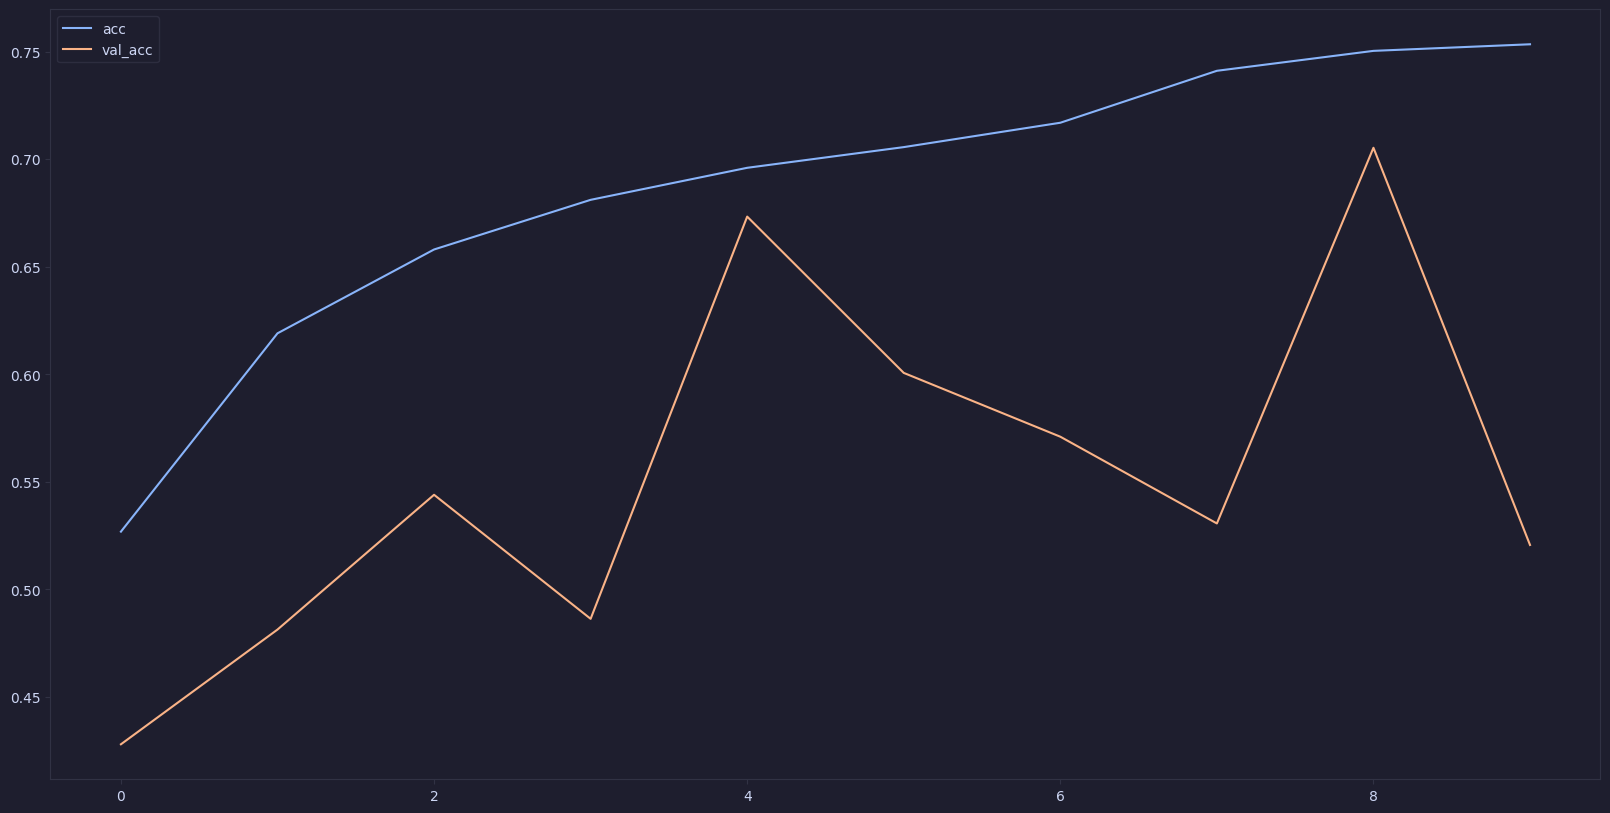

In [ ]:
acc = history.history["acc"]
val_acc = history.history["val_acc"]


plt.figure(figsize=(20, 10))
plt.plot(acc, label="acc")
plt.plot(val_acc, label="val_acc")
plt.legend()
plt.plot()

[]

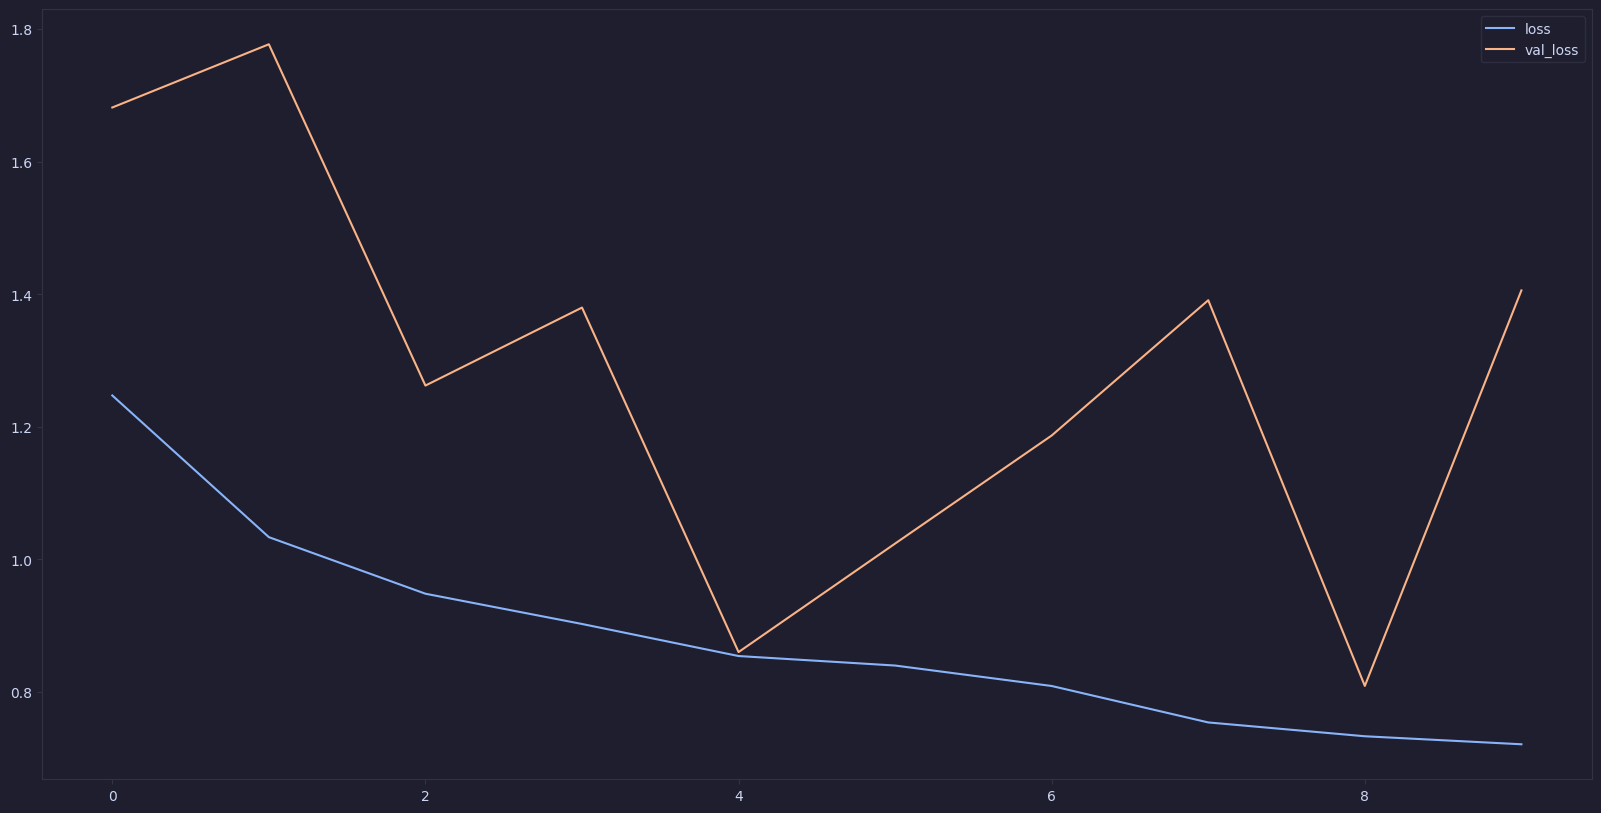

In [ ]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(20, 10))
plt.plot(loss, label="loss")
plt.plot(val_loss, label="val_loss")
plt.legend()
plt.plot()